# PFR Reaktionszone – Upscaling Framework


| Eigenschaft | Wert |
|---|---|
| Phase | Gas mit Molzahländerung |
| Temperaturregime | Isotherm |
| Kinetik | Austauschbar (Plug-and-Play) |
| Reaktion (Standard) | CH₄ + H₂O → CO + 3 H₂ |

Bei vorgegebenem Gesamtdurchsatz und Zielumsatz ergeben sich Strömungsgeschwindigkeit, Reaktionszonenlänge und Rohranzahl als zentrale Auslegungsvariablen. Die Strömungsgeschwindigkeit bestimmt die Verweilzeit und damit die erforderliche Rohrlänge, während die Rohranzahl über den Gesamtvolumenstrom mit der Strömungsgeschwindigkeit gekoppelt ist. Das optimale Design ergibt sich aus einem Kompromiss zwischen Reaktorlänge, Anzahl paralleler Rohre, Druckverlust, Wärmeübertragung und zulässigen Betriebsgrenzen.

$$
\dot V_{\text{gesamt}},\ X_{\text{target}}\ \text{gegeben}
\Rightarrow
u,\ L_R,\ N_{\text{Rohre}}\ \text{sind zentrale Designvariablen}
$$

Mit fester Rohrgeometrie ist eine Variable frei wählbar, zum Beispiel \(u\). Daraus folgen dann \(L_R\) und \(N_{\text{Rohre}}\).

---

## 1. Imports

In [ ]:
import numpy as np
from scipy.integrate import solve_ivp
import matplotlib.pyplot as plt
from dataclasses import dataclass, field
from typing import Callable, Dict

# Set up plotting
# command test

%matplotlib inline
plt.rcParams['figure.dpi'] = 130

## 2. Systemparameter

Alle Betriebsparameter an einem Ort. Geometrie, Druck, Temperatur und
Eintrittsbedingungen werden hier gesetzt.

In [78]:
@dataclass
class ReactorParams:
    """Betriebsparameter und Geometrie des Rohrreaktors."""

    # ── Geometrie ──────────────────────────────────────────────────────────
    d_i: float              # Innendurchmesser [m]

    # ── Betriebsbedingungen ────────────────────────────────────────────────
    T: float                # Temperatur [K]  –  isotherm
    p: float                # Eintrittsdruck [Pa]

    # ── Eintrittsbedingungen ───────────────────────────────────────────────
    u_0: float              # Eintrittsströmungsgeschwindigkeit [m/s]  ← Designvariable
    SC_ratio: float         # Steam-to-Carbon  = n_H2O,0 / n_CH4,0  [-]
    theta_CO2: float = 0.0  # Θ_CO2 = n_CO2,0 / n_CH4,0  [-]
    theta_N2:  float = 0.0  # Θ_N2  = n_N2,0  / n_CH4,0  [-]

    # ── Kinetikparameter (Platzhalter, nach Messungen ersetzen) ────────────
    k0_SMR:  float = 1.0    # Frequenzfaktor SMR   [mol/(m³·s)]
    Ea_SMR:  float = 0.0    # Aktivierungsenergie SMR [J/mol]
    k0_WGSR: float = 0.0    # Frequenzfaktor WGSR  [mol/(m³·s)]
    Ea_WGSR: float = 0.0    # Aktivierungsenergie WGSR [J/mol]

    # ── Fluideigenschaften ─────────────────────────────────────────────────
    mu: float = 3.0e-5      # Dyn. Viskosität [Pa·s]  (typisch ~800 °C)

    # ── Druckverlust-Modell ────────────────────────────────────────────────
    pressure_drop_model: str = 'ergun'   # 'ergun' oder 'darcy_weisbach'
    epsilon_B:           float = 0.4     # Bettporosität [-]         (Ergun)
    d_p:                 float = 3e-3    # Partikeldurchmesser [m]   (Ergun)
    epsilon_roughness:   float = 0.0     # Rohrrauheit [m]  (Darcy-Weisbach)

    # ── Gesamtdurchsatz (für Rohranzahl-Berechnung) ───────────────────────
    n_dot_A0_total: float = 0.1         # Gesamt-CH4-Molstrom [mol/s]

    # ══ Abgeleitete Größen ═════════════════════════════════════════════════

    @property
    def A_q(self) -> float:
        """Rohrquerschnittsfläche [m²]."""
        return np.pi / 4 * self.d_i ** 2

    @property
    def Phi_0(self) -> float:
        """Normierter Gesamtmolenstrom am Eintritt: Φ₀ = 1 + S/C + Θ_CO2 + Θ_N2."""
        return 1.0 + self.SC_ratio + self.theta_CO2 + self.theta_N2

    @property
    def y_A0(self) -> float:
        """Molenbruch CH4 am Eintritt [-]."""
        return 1.0 / self.Phi_0

    @property
    def c_total_inlet(self) -> float:
        """Gesamtkonzentration am Eintritt [mol/m³] (ideales Gas, Eintrittsdruck)."""
        return self.p / (8.314 * self.T)

    @property
    def c_A0(self) -> float:
        """Eintrittskonzentration CH4 [mol/m³]."""
        return self.y_A0 * self.c_total_inlet

    @property
    def n_dot_A0_per_tube(self) -> float:
        """CH4-Molstrom pro Rohr [mol/s]."""
        return self.c_A0 * self.u_0 * self.A_q

    @property
    def N_tubes(self) -> int:
        """Anzahl paralleler Rohre (aufgerundet)."""
        return int(np.ceil(self.n_dot_A0_total / self.n_dot_A0_per_tube))


# ── Ausgabe ──────────────────────────────────────────────────────────────────
params = ReactorParams(
    d_i              = 0.02,       # 50 mm Innendurchmesser
    T                = 1373.15,    # 1100 °C
    p                = 50e5,       # 20 bar
    u_0              = 0.5,        # Eintrittsgeschwindigkeit [m/s]  ← Designvariable
    SC_ratio         = 2.5,
    theta_CO2        = 0.01,
    theta_N2         = 0.1,
    k0_SMR           = 1.948e10,   # m^6/(s mol^2)
    Ea_SMR           = 281.6e3,    # J/mol
    k0_WGSR          = 2.981e-1,   # m^6/(s mol^2)
    Ea_WGSR          = 20.0e3,     # J/mol
    mu               = 3.0e-5,
    pressure_drop_model = 'darcy-weisbach',
    epsilon_B        = 0.4,
    d_p              = 3e-3,
    n_dot_A0_total   = 0.1,
)

print(f"=== Systemparameter ===")
print(f"d_i               = {params.d_i*1e3:.1f} mm")
print(f"T                 = {params.T:.2f} K  ({params.T-273.15:.0f} °C)")
print(f"p_0               = {params.p/1e5:.1f} bar")
print(f"u_0               = {params.u_0:.3f} m/s")
print(f"S/C               = {params.SC_ratio}")
print(f"Φ_0               = {params.Phi_0:.2f}")
print(f"c_CH4,0           = {params.c_A0:.3f} mol/m³")
print(f"ṅ_CH4 pro Rohr    = {params.n_dot_A0_per_tube*1e3:.4f} mmol/s")
print(f"N_Rohre           = {params.N_tubes}")

=== Systemparameter ===
d_i               = 20.0 mm
T                 = 1373.15 K  (1100 °C)
p_0               = 50.0 bar
u_0               = 0.500 m/s
S/C               = 2.5
Φ_0               = 3.61
c_CH4,0           = 121.321 mol/m³
ṅ_CH4 pro Rohr    = 19.0570 mmol/s
N_Rohre           = 6


## 3. Konzentrationsmodell mit SMR, WGSR, CO₂-Feed und N₂-Feed

Für die Reaktionszone werden die Konzentrationen der Komponenten als Funktion zweier Reaktionsvariablen beschrieben:

$$
X = \frac{\xi_{\text{SMR}}}{\dot n_{CH_4,0}}
$$

$$
Y = \frac{\xi_{\text{WGSR}}}{\dot n_{CH_4,0}}
$$

Dabei beschreibt \(X\) den normierten Fortschritt der Steam-Methane-Reforming-Reaktion und \(Y\) den normierten Fortschritt der Water-Gas-Shift-Reaktion.

Berücksichtigt werden die Reaktionen:

$$
\mathrm{CH_4 + H_2O \rightarrow CO + 3H_2}
$$

$$
\mathrm{CO + H_2O \rightleftharpoons CO_2 + H_2}
$$

---

### 3.1 Normierte Feed-Zusammensetzung

Als Bezugsgröße wird der Eintrittsstoffmengenstrom von Methan verwendet:

$$
\dot n_{CH_4,0}
$$

Die Feed-Zusammensetzung wird relativ zu Methan beschrieben:

$$
\Theta_{H_2O,0}
=
\frac{\dot n_{H_2O,0}}{\dot n_{CH_4,0}}
=
S/C
$$

$$
\Theta_{CO_2,0}
=
\frac{\dot n_{CO_2,0}}{\dot n_{CH_4,0}}
$$

$$
\Theta_{N_2,0}
=
\frac{\dot n_{N_2,0}}{\dot n_{CH_4,0}}
$$

Methan selbst besitzt damit den normierten Eintrittsstrom:

$$
\Theta_{CH_4,0}=1
$$

---

### 3.2 Stoffmengenströme als Funktion von \(X\) und \(Y\)

Für die Komponenten ergeben sich die normierten Stoffmengenströme:

$$
\frac{\dot n_{CH_4}}{\dot n_{CH_4,0}}
=
1-X
$$

$$
\frac{\dot n_{H_2O}}{\dot n_{CH_4,0}}
=
S/C - X - Y
$$

$$
\frac{\dot n_{CO}}{\dot n_{CH_4,0}}
=
X - Y
$$

$$
\frac{\dot n_{H_2}}{\dot n_{CH_4,0}}
=
3X + Y
$$

$$
\frac{\dot n_{CO_2}}{\dot n_{CH_4,0}}
=
\Theta_{CO_2,0} + Y
$$

$$
\frac{\dot n_{N_2}}{\dot n_{CH_4,0}}
=
\Theta_{N_2,0}
$$

Stickstoff wird als inert betrachtet und nimmt nicht an den Reaktionen teil.

---

### 3.3 Gesamtstoffmengenstrom

Der relative Gesamtstoffmengenstrom ergibt sich aus der Summe aller normierten Stoffmengenströme:

$$
\frac{\dot n_{\text{ges}}}{\dot n_{CH_4,0}}
=
(1-X)
+
(S/C-X-Y)
+
(X-Y)
+
(3X+Y)
+
(\Theta_{CO_2,0}+Y)
+
\Theta_{N_2,0}
$$

Zusammengefasst:

$$
\boxed{
\frac{\dot n_{\text{ges}}}{\dot n_{CH_4,0}}
=
1
+
S/C
+
\Theta_{CO_2,0}
+
\Theta_{N_2,0}
+
2X
}
$$

Die Water-Gas-Shift-Reaktion verändert den Gesamtstoffmengenstrom nicht, da auf beiden Seiten jeweils zwei Mol Gas stehen:

$$
\Delta \nu_{\text{WGSR}} = 0
$$

Die Steam-Methane-Reforming-Reaktion erhöht dagegen die Gesamtmolzahl um zwei:

$$
\Delta \nu_{\text{SMR}} = 2
$$

---

### 3.4 Molenbrüche

Der Molenbruch einer Komponente ist:

$$
y_i(X,Y)
=
\frac{\dot n_i(X,Y)}{\dot n_{\text{ges}}(X)}
$$

Damit ergeben sich:

$$
\boxed{
y_{CH_4}
=
\frac{1-X}
{1+S/C+\Theta_{CO_2,0}+\Theta_{N_2,0}+2X}
}
$$

$$
\boxed{
y_{H_2O}
=
\frac{S/C-X-Y}
{1+S/C+\Theta_{CO_2,0}+\Theta_{N_2,0}+2X}
}
$$

$$
\boxed{
y_{CO}
=
\frac{X-Y}
{1+S/C+\Theta_{CO_2,0}+\Theta_{N_2,0}+2X}
}
$$

$$
\boxed{
y_{H_2}
=
\frac{3X+Y}
{1+S/C+\Theta_{CO_2,0}+\Theta_{N_2,0}+2X}
}
$$

$$
\boxed{
y_{CO_2}
=
\frac{\Theta_{CO_2,0}+Y}
{1+S/C+\Theta_{CO_2,0}+\Theta_{N_2,0}+2X}
}
$$

$$
\boxed{
y_{N_2}
=
\frac{\Theta_{N_2,0}}
{1+S/C+\Theta_{CO_2,0}+\Theta_{N_2,0}+2X}
}
$$

---

### 3.5 Konzentrationen

Für ein ideales Gas gilt:

$$
c_{\text{ges}}
=
\frac{p}{RT}
$$

Die Konzentration einer Komponente ergibt sich aus:

$$
c_i
=
y_i
\cdot
c_{\text{ges}}
$$

Damit lautet die allgemeine Konzentrationsfunktion:

$$
\boxed{
c_i(X,Y)
=
y_i(X,Y)
\cdot
\frac{p}{RT}
}
$$

Die Konzentrationen sind somit Funktionen von Umsatz \(X\), WGSR-Fortschritt \(Y\), Temperatur, Druck und Feed-Zusammensetzung:

$$
\boxed{
c_i
=
c_i(X,Y,T,p,S/C,\Theta_{CO_2,0},\Theta_{N_2,0})
}
$$

### 3.6 Strömungsgeschwindigkeit als Funktion von X und p

Da die Molzahl durch die SMR-Reaktion zunimmt (Δν = +2 pro Mol CH₄), ändert sich der
Volumenstrom entlang der Reaktionslänge — auch bei konstantem Druck.

Aus der molaren Flussbilanz und dem idealen Gasgesetz gilt an jeder Stelle:

$$
\dot V(X) = \dot n_{\text{ges}}(X) \cdot \frac{RT}{p(L)}
$$

Mit dem normierten Gesamtmolenstrom

$$
\frac{\dot n_{\text{ges}}(X)}{\dot n_{CH_4,0}} = \Phi_0 + 2X, \qquad
\Phi_0 = 1 + S/C + \Theta_{CO_2,0} + \Theta_{N_2,0}
$$

und dem Eintrittswert

$$
u_0 = \frac{\dot n_{\text{ges},0} \cdot RT}{p_0 \cdot A_q}
= \frac{\dot n_{CH_4,0} \cdot \Phi_0 \cdot RT}{p_0 \cdot A_q}
$$

folgt durch Division:

$$
\boxed{
u(X, p)
=
u_0
\cdot
\frac{\Phi_0 + 2X}{\Phi_0}
\cdot
\frac{p_0}{p(L)}
}
$$

Die Geschwindigkeit steigt also mit zunehmendem Umsatz (Molzahlzunahme) und sinkt mit
zunehmendem Druck. Beide Effekte müssen entlang der Reaktorlänge verfolgt werden.

### 3.7 Gasdichte als Funktion von X, Y und p

Für ein ideales Gasgemisch gilt:

$$
\rho(X, Y, p) = \frac{p \cdot M_{\text{mix}}(X, Y)}{RT}
$$

Die mittlere Molmasse des Gemisches ergibt sich aus den Molenbrüchen:

$$
M_{\text{mix}}(X, Y) = \sum_i y_i(X, Y) \cdot M_i
$$

mit den Reinstoff-Molmassen:

| Komponente | $M_i$ [g/mol] |
|---|---|
| CH₄ | 16.04 |
| H₂O | 18.02 |
| CO  | 28.01 |
| H₂  | 2.016 |
| CO₂ | 44.01 |
| N₂  | 28.01 |

Die Dichte hängt damit gleichzeitig von Zusammensetzung (X, Y) und Druck p(L) ab.
Beide ändern sich entlang der Reaktionszone.

### 3.8 Zusammenfassung: Abhängigkeiten entlang der Reaktorlänge

| Größe | Abhängigkeit | Gleichung |
|---|---|---|
| $c_i(L)$ | $X(L),\ Y(L),\ p(L)$ | $c_i = y_i(X,Y) \cdot p/(RT)$ |
| $u(L)$   | $X(L),\ p(L)$          | $u = u_0 \cdot (\Phi_0+2X)/\Phi_0 \cdot p_0/p$ |
| $\rho(L)$| $X(L),\ Y(L),\ p(L)$ | $\rho = p \cdot M_{\text{mix}}(X,Y)/(RT)$ |
| $p(L)$   | $u(L),\ \rho(L)$      | $dp/dL = -f(u,\rho)$ (Darcy-Weisbach oder Ergun) |

Alle vier Größen sind über das ODE-System miteinander gekoppelt.

In [79]:
# ══════════════════════════════════════════════════════════════════════════════
# Molare Molmassen [kg/mol]
# ══════════════════════════════════════════════════════════════════════════════
MOLAR_MASS = {
    'CH4': 16.04e-3,
    'H2O': 18.02e-3,
    'CO':  28.01e-3,
    'H2':  2.016e-3,
    'CO2': 44.01e-3,
    'N2':  28.01e-3,
}


def get_mole_flow_ratios(X: float, Y: float, params: ReactorParams) -> Dict[str, float]:
    """
    Normierte Molenstrome ṅ_i / ṅ_CH4,0 als Funktion von X und Y.

        CH4 :  1 - X
        H2O :  S/C - X - Y
        CO  :  X - Y
        H2  :  3X + Y
        CO2 :  Θ_CO2 + Y
        N2  :  Θ_N2   (inert)
    """
    SC  = params.SC_ratio
    return {
        'CH4': 1.0 - X,
        'H2O': SC - X - Y,
        'CO':  X - Y,
        'H2':  3.0 * X + Y,
        'CO2': params.theta_CO2 + Y,
        'N2':  params.theta_N2,
    }


def get_total_flow_ratio(X: float, params: ReactorParams) -> float:
    """
    Normierter Gesamtmolenstrom ṅ_ges / ṅ_CH4,0 = Φ_0 + 2X.
    (WGSR verändert die Gesamtmolzahl nicht: Δν_WGSR = 0)
    """
    return params.Phi_0 + 2.0 * X


def get_mole_fractions(X: float, Y: float, params: ReactorParams) -> Dict[str, float]:
    """
    Molenbrüche y_i(X, Y) = ṅ_i / ṅ_ges.
    """
    flows   = get_mole_flow_ratios(X, Y, params)
    n_total = get_total_flow_ratio(X, params)
    return {k: max(v / n_total, 0.0) for k, v in flows.items()}


def get_concentrations(X: float, Y: float, p: float,
                       params: ReactorParams) -> Dict[str, float]:
    """
    Konzentrationen c_i(X, Y, p) [mol/m³] für ideales Gas.

        c_i = y_i(X, Y) · p / (R·T)

    Beide Reaktionsfortschritte X und Y sowie der lokale Druck p gehen ein.
    """
    R       = 8.314
    c_total = p / (R * params.T)
    y       = get_mole_fractions(X, Y, params)
    return {k: v * c_total for k, v in y.items()}


def get_velocity(X: float, p: float, params: ReactorParams) -> float:
    """
    Lokale Strömungsgeschwindigkeit u(X, p) [m/s].

    Aus Molenstrom-Bilanz und idealem Gasgesetz:

        u(X, p) = u_0 · (Φ_0 + 2X) / Φ_0 · p_0 / p

    Steigt mit X (Molzahlzunahme durch SMR) und sinkt mit p (Druckverlust).
    """
    Phi = get_total_flow_ratio(X, params)
    return params.u_0 * (Phi / params.Phi_0) * (params.p / p)


def get_molar_mass_mix(X: float, Y: float, params: ReactorParams) -> float:
    """Mittlere Molmasse des Gasgemisches M_mix(X, Y) [kg/mol]."""
    y = get_mole_fractions(X, Y, params)
    return sum(y[k] * MOLAR_MASS[k] for k in MOLAR_MASS)


def get_density(X: float, Y: float, p: float, params: ReactorParams) -> float:
    """
    Gasdichte ρ(X, Y, p) [kg/m³] für ideales Gas.

        ρ = p · M_mix(X, Y) / (R · T)
    """
    R     = 8.314
    M_mix = get_molar_mass_mix(X, Y, params)
    return p * M_mix / (R * params.T)


# ── Beispielausgabe am Eintritt ───────────────────────────────────────────────
X0, Y0, p0 = 0.0, 0.0, params.p
print(f"=== Zustand am Eintritt (X=0, Y=0) ===")
c0  = get_concentrations(X0, Y0, p0, params)
u0  = get_velocity(X0, p0, params)
rho0 = get_density(X0, Y0, p0, params)
for k, v in c0.items():
    print(f"  c_{k:<4s} = {v:.3f} mol/m³")
print(f"  u     = {u0:.4f} m/s")
print(f"  ρ     = {rho0:.4f} kg/m³")

=== Zustand am Eintritt (X=0, Y=0) ===
  c_CH4  = 121.321 mol/m³
  c_H2O  = 303.302 mol/m³
  c_CO   = 0.000 mol/m³
  c_H2   = 0.000 mol/m³
  c_CO2  = 1.213 mol/m³
  c_N2   = 12.132 mol/m³
  u     = 0.5000 m/s
  ρ     = 7.8047 kg/m³


## 4. Kinetikmodell mit reversiblen Arrhenius-Gleichungen

Für das Reaktionsmodell werden zwei reversible Reaktionen berücksichtigt:

$$
\mathrm{CH_4 + H_2O \rightleftharpoons CO + 3H_2}
$$

$$
\mathrm{CO + H_2O \rightleftharpoons CO_2 + H_2}
$$

---

### 4.1 Reaktionsgeschwindigkeit SMR

$$
\boxed{
r_{\text{SMR}}
=
k_{\text{SMR}} \cdot \exp\!\left(-\frac{E_{A,\text{SMR}}}{RT}\right)
\cdot
\left(
c_{\text{CH}_4} \cdot c_{\text{H}_2\text{O}} \cdot c_{N_2}
-
\frac{c_{\text{CO}} \cdot c_{\text{H}_2}^3 \cdot c_{N_2}}{K^{eq}_{\text{SMR}}}
\right)
}
$$

| Symbol | Bedeutung |
|---|---|
| $k_{\text{SMR}}$ | Frequenzfaktor der SMR-Reaktion [m⁶/(mol²·s)] |
| $E_{A,\text{SMR}}$ | Aktivierungsenergie der SMR-Reaktion [J/mol] |
| $K^{eq}_{\text{SMR}}$ | Gleichgewichtskonstante der SMR [mol²/m⁶] |

---

### 4.2 Reaktionsgeschwindigkeit WGS

$$
\boxed{
r_{\text{WGS}}
=
k_{\text{WGS}} \cdot \exp\!\left(-\frac{E_{A,\text{WGS}}}{RT}\right)
\cdot
\left(
c_{\text{CO}} \cdot c_{\text{H}_2\text{O}} \cdot c_{N_2}
-
\frac{c_{\text{CO}_2} \cdot c_{\text{H}_2} \cdot c_{N_2}}{K^{eq}_{\text{WGS}}}
\right)
}
$$

| Symbol | Bedeutung |
|---|---|
| $k_{\text{WGS}}$ | Frequenzfaktor der WGS-Reaktion [m⁶/(mol²·s)] |
| $E_{A,\text{WGS}}$ | Aktivierungsenergie der WGS-Reaktion [J/mol] |
| $K^{eq}_{\text{WGS}}$ | Gleichgewichtskonstante der WGS [-] |

---

### 4.3 Einheiten

Da $c_{N_2}$ in beiden Termen vorkommt, kürzt es sich bei der Definition von $K^{eq}$ heraus
— $K^{eq}$ behält damit dieselbe Definition wie ohne $N_2$.

Einheitenanalyse für SMR mit Vorwärtsterm 3. Ordnung:

$$
[r_{\text{SMR}}]
=
\underbrace{\left[\frac{\text{m}^6}{\text{mol}^2 \cdot \text{s}}\right]}_{k}
\cdot
\underbrace{\left[\frac{\text{mol}^3}{\text{m}^9}\right]}_{c_{CH_4}\cdot c_{H_2O} \cdot c_{N_2}}
=
\frac{\text{mol}}{\text{m}^3 \cdot \text{s}} \checkmark
$$

---

### 4.4 Gleichgewichtskonstanten

Die molenbruchbasierte Gleichgewichtskonstante $K_y$ ergibt sich aus:

$$
K_y = \frac{K(T)}{K_\phi} \left(\frac{p}{p^0}\right)^{-\sum_{j=1}^{J} \nu_j}
$$

**Annahme:** Da ideal gerechnet wird, gilt $K_\phi = 1$. Die Formel vereinfacht sich zu:

$$
K_y = K(T) \left(\frac{p}{p^0}\right)^{-\sum_{j=1}^{J} \nu_j}
$$

Für die beiden Reaktionen:

| Reaktion | $\sum \nu_j$ | $K_y$ |
|---|---|---|
| SMR: CH₄ + H₂O ⇌ CO + 3H₂ | $+2$ | $K_y^{\text{SMR}} = K(T)_{\text{SMR}} \cdot (p/p^0)^{-2}$ |
| WGS: CO + H₂O ⇌ CO₂ + H₂ | $0$ | $K_y^{\text{WGS}} = K(T)_{\text{WGS}}$ |

Da die Reaktionsraten konzentrationsbasiert formuliert sind (vgl. Abschnitt 4.1–4.2), wird $K_y$ in die konzentrationsbasierte Größe $K_c$ umgerechnet. Mit $y_i = c_i \cdot RT/p$ gilt:

$$
K_c = K_y \cdot \left(\frac{p}{RT}\right)^{\sum_j \nu_j}
$$

Einsetzen von $K_y$ liefert nach Vereinfachung:

$$
K_c = K(T) \cdot \left(\frac{p^0}{RT}\right)^{\sum_j \nu_j}
$$

Das Ergebnis ist **druckunabhängig**, da sich $p$ herauskürzt. Damit gilt konkret:

$$
\boxed{
K_c^{\text{SMR}} = K(T)_{\text{SMR}} \cdot \left(\frac{p^0}{RT}\right)^{2}
\qquad
K_c^{\text{WGS}} = K(T)_{\text{WGS}}
}
$$

#### Bestimmung von $K(T)$

Die thermodynamische Gleichgewichtskonstante $K(T)$ ist über die **standardmäßige freie Reaktionsenthalpie** $\Delta g^\circ_R(T)$ definiert:

$$
\boxed{K(T) = \exp\!\left(-\frac{\Delta g^\circ_R(T)}{RT}\right)}
$$

Die freie Reaktionsenthalpie ergibt sich aus Reaktionsenthalpie und Reaktionsentropie:

$$
\Delta g^\circ_R(T) = \Delta h^*_R(p^0,T) - T \cdot \Delta s^*_R(p^0,T)
$$

Beide Größen werden aus den stöchiometrisch gewichteten Bildungsenthalpien bzw. Entropien der Reinstoffe berechnet:

$$
\Delta h^*_R(T) = \sum_j \nu_j \cdot \Delta h^\circ_{f,j}(T)
\qquad
\Delta s^*_R(T) = \sum_j \nu_j \cdot s^\circ_j(T)
$$

Die temperaturabhängigen Größen lassen sich aus tabellierten Standardbildungsenthalpien bzw. Standardentropien und einer Temperaturkorretur bestimmen:

$$
h^\circ_{f,j}(T)=\Delta h_j^0+\int_{T^0}^{T} c_{p,j}^\ast(T)\, dT
\qquad
s^\circ_j(T)=s_j^0+\int_{T^0}^{T}\frac{c_{p,j}^\ast(T)}{T}\,dT
$$

> **Hinweis:** $h^\circ_{f,j}(T)$ und $s^\circ_j(T)$ wird direkt aus **Cantera** bezogen. Cantera wertet dafür die NASA-7-Koeffizientenpolynome jeder Spezies einzeln aus – kein Mischungseffekt, keine Wechselwirkung zwischen den Komponenten.

#### $K(T)$ im numerischen ODE-System

$K^{eq}$ hängt **ausschließlich von der Temperatur** ab – nicht von den Konzentrationen. Dies folgt direkt aus der thermodynamischen Definition über $\Delta g^\circ_R(T)$. Die Konzentrationen erscheinen zwar in der Ratengleichung (Vorwärts- und Rückwärtsterm), beeinflussen aber $K^{eq}$ selbst nicht.

Bei **isothermem Betrieb** ($T = \text{const.}$) gilt daher:

$$
K^{eq} = \text{const.} \quad \text{entlang der gesamten Reaktorlänge}
$$

$K^{eq}$ wird deshalb **einmalig zu Beginn der Simulation** berechnet und für alle ODE-Schritte wiederverwendet. Dies geschieht im Code über `lru_cache`: Cantera wird nur beim ersten Aufruf eines neuen $T$-Werts ausgeführt, jeder weitere Aufruf mit demselben $T$ liefert das gecachte Ergebnis ohne erneuten Rechenaufwand.

---

### 4.5 Kopplung mit den Reaktionsvariablen

$$
\boxed{
\frac{dX}{dL}
=
\frac{r_{\text{SMR}}\bigl(c_i(X,Y,p),\,T\bigr)}{c_{\text{CH}_4,0} \cdot u_0}
}
\qquad
\boxed{
\frac{dY}{dL}
=
\frac{r_{\text{WGS}}\bigl(c_i(X,Y,p),\,T\bigr)}{c_{\text{CH}_4,0} \cdot u_0}
}
$$

Die Rückwärtsterme führen dazu, dass $dX/dL \to 0$ sobald das Gleichgewicht erreicht wird —
der Reaktor hat damit einen **maximalen Gleichgewichtsumsatz** $X_{eq}(T, p)$.

In [80]:
# ══════════════════════════════════════════════════════════════════════════════
# Gleichgewichtskonstanten  –  berechnet über Cantera (NASA-Polynome, GRI30)
# ══════════════════════════════════════════════════════════════════════════════
import cantera as ct
from functools import lru_cache

# Cantera-Lösung einmalig laden (GRI-Mech 3.0 enthält alle benötigten Spezies)
_gas_ct = ct.Solution('gri30.yaml')
_sp_idx = {sp: _gas_ct.species_index(sp)
           for sp in ['CH4', 'H2O', 'CO', 'H2', 'CO2']}
_R  = 8.314   # J/(mol·K)
_P0 = 1e5     # Referenzdruck p⁰ = 1 bar [Pa]


@lru_cache(maxsize=128)
def _K_T_cantera(T: float):
    """
    Berechnet K(T) für SMR und WGS über Cantera-Thermodynamik (NASA-Polynome).

    Cantera gibt dimensionslose Größen zurück:
        standard_enthalpies_RT  →  h°j / (R·T)   [-]
        standard_entropies_R    →  s°j / R        [-]

    Damit gilt direkt (dimensionslos):
        g°j / (R·T) = h°j/(R·T)  −  s°j/R
        K(T) = exp(−Σ νj · g°j/(R·T))

    Keine Umrechnung in J/mol nötig – die R·T kürzen sich heraus.

    Rückgabe
    --------
    K_T_SMR, K_T_WGS : float, dimensionslos

    Hinweis: @lru_cache speichert das Ergebnis für jeden T-Wert – bei
    isothermer Simulation wird Cantera nur beim allerersten Aufruf ausgeführt.
    """
    _gas_ct.TP = T, ct.one_atm

    # Dimensionsloses g°j/(R·T) = h°j/(R·T) − s°j/R  für alle Spezies
    g_over_RT = _gas_ct.standard_enthalpies_RT - _gas_ct.standard_entropies_R

    # SMR: CH4 + H2O ⇌ CO + 3 H2   (Δν = +2)
    dg_over_RT_SMR = (  g_over_RT[_sp_idx['CO']]
                      + 3 * g_over_RT[_sp_idx['H2']]
                      - g_over_RT[_sp_idx['CH4']]
                      - g_over_RT[_sp_idx['H2O']])

    # WGS: CO + H2O ⇌ CO2 + H2     (Δν =  0)
    dg_over_RT_WGS = (  g_over_RT[_sp_idx['CO2']]
                      + g_over_RT[_sp_idx['H2']]
                      - g_over_RT[_sp_idx['CO']]
                      - g_over_RT[_sp_idx['H2O']])

    K_T_SMR = np.exp(-dg_over_RT_SMR)
    K_T_WGS = np.exp(-dg_over_RT_WGS)
    return K_T_SMR, K_T_WGS


def K_eq_SMR(T: float) -> float:
    """
    Konzentrationsbasierte Gleichgewichtskonstante der SMR [mol²/m⁶].

    Herleitung (K_φ = 1, ideal):
        K(T)  = exp(−Δg°_R / (R·T))        ← via Cantera
        K_y   = K(T) · (p/p⁰)^(−Δν)
        K_c   = K_y  · (p/RT)^Δν
              = K(T) · (p⁰/RT)^Δν          ← p kürzt sich heraus

    Mit Δν_SMR = +2:
        K_c = K(T) · (p⁰/RT)²
    """
    K_T_SMR, _ = _K_T_cantera(T)
    return K_T_SMR * (_P0 / (_R * T)) ** 2


def K_eq_WGS(T: float) -> float:
    """
    Konzentrationsbasierte Gleichgewichtskonstante der WGS [-].

    Herleitung (K_φ = 1, ideal):
        K(T) = exp(−Δg°_R / (R·T))         ← via Cantera
        Δν_WGS = 0  →  K_c = K(T)
    """
    _, K_T_WGS = _K_T_cantera(T)
    return K_T_WGS   # Δν = 0  →  K_c = K_y = K(T)


# ── Kurzer Plausibilitätscheck bei T = 1100 °C ────────────────────────────────
_T_test = 1373.15
print(f"Plausibilitätscheck bei T = {_T_test:.2f} K ({_T_test-273.15:.0f} °C):")
print(f"  K_c,SMR = {K_eq_SMR(_T_test):.4e} mol²/m⁶")
print(f"  K_c,WGS = {K_eq_WGS(_T_test):.4f} [-]")
print(f"  Cache-Info: {_K_T_cantera.cache_info()}")


# ══════════════════════════════════════════════════════════════════════════════
# Kinetik-Funktion  (reversibel mit c_N2, Gleichungen 6 & 7 aus Quelle)
# ══════════════════════════════════════════════════════════════════════════════

def rate_law_reforming(conc: Dict[str, float],
                        T: float,
                        params: ReactorParams):
    """
    Reversible Kinetik (Quelle, Gl. 6 & 7) mit c_N2 in Hin- und Rückreaktion:

        r_SMR = k_SMR · exp(-Ea_SMR/RT) · (c_CH4·c_H2O·c_N2  -  c_CO·c_H2³·c_N2 / K_c,SMR)
        r_WGS = k_WGS · exp(-Ea_WGS/RT) · (c_CO·c_H2O·c_N2   -  c_CO2·c_H2·c_N2 / K_c,WGS)

    c_N2 kürzt sich in K_eq heraus – beeinflusst aber die Reaktionsrate (3. Ordnung).

    Einheiten:
        k_SMR, k_WGS  :  m⁶/(mol²·s)
        r_SMR, r_WGS  :  mol/(m³·s)

    Hinweis: _K_T_cantera(T) wird einmal pro T-Wert aufgerufen (lru_cache).
    Bei isothermer Simulation entspricht das genau einem einzigen Cantera-Aufruf
    für die gesamte ODE-Integration.
    """
    R  = 8.314
    k1 = params.k0_SMR  * np.exp(-params.Ea_SMR  / (R * T))
    k2 = params.k0_WGSR * np.exp(-params.Ea_WGSR / (R * T))

    # lru_cache stellt sicher, dass _K_T_cantera(T) nur einmal pro T-Wert ausgeführt wird
    Keq_SMR = K_eq_SMR(T)   # K_c,SMR [mol²/m⁶]
    Keq_WGS = K_eq_WGS(T)   # K_c,WGS [-]

    cN2 = conc['N2']

    # ── SMR: CH4 + H2O ⇌ CO + 3H2 ───────────────────────────────────────
    forward_SMR  = conc['CH4'] * conc['H2O'] * cN2
    backward_SMR = conc['CO']  * max(conc['H2'], 0.0)**3 * cN2 / Keq_SMR
    r_SMR = k1 * (forward_SMR - backward_SMR)

    # ── WGS: CO + H2O ⇌ CO2 + H2 ────────────────────────────────────────
    forward_WGS  = conc['CO']  * conc['H2O'] * cN2
    backward_WGS = conc['CO2'] * conc['H2']  * cN2 / Keq_WGS
    r_WGS = k2 * (forward_WGS - backward_WGS)

    return r_SMR, r_WGS


def rate_law_custom(conc: Dict[str, float],
                    T: float,
                    params: ReactorParams):
    """Platzhalter für weitere Kinetiken. Gibt (r_SMR, r_WGS) zurück."""
    raise NotImplementedError("Eigene Kinetik hier implementieren.")



# Reaktionsraten am Einlass (X=0, Y=0) – Konzentrationen aus params
_c_tot   = params.p / (_R * params.T)   # Ideales Gas: c = p/(R·T)  [mol/m³]
_denom   = 1 + params.SC_ratio + params.theta_CO2 + params.theta_N2
_conc_in = {
    'CH4': _c_tot / _denom,
    'H2O': _c_tot * params.SC_ratio  / _denom,
    'CO':  1e-10,
    'H2':  1e-10,   # numerische Regularisierung
    'CO2': _c_tot * params.theta_CO2 / _denom,
    'N2':  _c_tot * params.theta_N2  / _denom,
}
_r_SMR, _r_WGS = rate_law_reforming(_conc_in, params.T, params)
print(f"  r_SMR  = {_r_SMR:.4e} mol/(m³·s)  (Einlass, X=0)")
print(f"  r_WGS  = {_r_WGS:.4e} mol/(m³·s)  (Einlass, Y=0)")

Plausibilitätscheck bei T = 1373.15 K (1100 °C):
  K_c,SMR = 3.2565e+06 mol²/m⁶
  K_c,WGS = 0.4856 [-]
  Cache-Info: CacheInfo(hits=1, misses=1, maxsize=128, currsize=1)
  r_SMR  = 1.6861e+05 mol/(m³·s)  (Einlass, X=0)
  r_WGS  = 1.8869e-08 mol/(m³·s)  (Einlass, Y=0)


## 5. Auslegungsvariablen 

Strömungsgeschwindigkeit als unabhängige Variable zur Bestimmung von Rohrlänge und Rohranzahl.
$$
u,\ L_R(u),\ N_{\text{Rohre}}(u)
$$

## 5.1 Herleitung der PFR-Auslegungsgleichung mit Strömungsgeschwindigkeit

Ziel ist es, die Reaktionszonenlänge nicht direkt über den Eintrittsstoffmengenstrom, sondern über die Eintritts-Strömungsgeschwindigkeit zu beschreiben:

$$
L_R = L_R(u_0)
$$

---

### 5.1.1 Stoffbilanz für ein differentielles Rohrsegment

Betrachtet wird ein differentielles Volumenelement eines idealen Rohrreaktors:

$$
dV = A_q \cdot dL
$$

Für die Schlüsselkomponente A gilt im stationären Zustand:

$$
\text{Zustrom} - \text{Abstrom} - \text{Verbrauch durch Reaktion} = 0
$$

Der Stoffmengenstrom von A nimmt entlang der Reaktorlänge ab. Für ein differentielles Segment gilt daher:

$$
d\dot n_A = r_A \cdot dV
$$

Da A verbraucht wird, ist \(r_A < 0\). Mit der positiven Verbrauchsrate

$$
(-r_A) > 0
$$

ergibt sich:

$$
-d\dot n_A = (-r_A) \cdot dV
$$

---

### 5.1.2 Einführung des Umsatzes

Der Umsatz der Schlüsselkomponente A ist definiert als:

$$
X =
\frac{\dot n_{A,0} - \dot n_A}{\dot n_{A,0}}
$$

Umgestellt nach dem Stoffmengenstrom:

$$
\dot n_A = \dot n_{A,0}(1-X)
$$

Differentiation liefert:

$$
d\dot n_A = -\dot n_{A,0} \cdot dX
$$

Damit gilt:

$$
-d\dot n_A = \dot n_{A,0} \cdot dX
$$

---

### 5.1.3 Einsetzen in die Stoffbilanz

Aus der Stoffbilanz:

$$
-d\dot n_A = (-r_A) \cdot dV
$$

und der Umsatzdefinition:

$$
-d\dot n_A = \dot n_{A,0} \cdot dX
$$

folgt:

$$
\dot n_{A,0} \cdot dX = (-r_A) \cdot dV
$$

Umstellen ergibt:

$$
\frac{dX}{dV}
=
\frac{(-r_A)}{\dot n_{A,0}}
$$

Da für ein Rohrsegment gilt:

$$
dV = A_q \cdot dL
$$

folgt:

$$
\frac{dV}{dL} = A_q
$$

Mit der Kettenregel:

$$
\frac{dX}{dL}
=
\frac{dX}{dV}
\cdot
\frac{dV}{dL}
$$

ergibt sich die PFR-Auslegungsgleichung bezogen auf die Rohrlänge:

$$
\frac{dX}{dL}
=
\frac{A_q \cdot (-r_A)}{\dot n_{A,0}}
$$

---

### 5.1.4 Umschreibung des Eintrittsstoffmengenstroms über die Strömungsgeschwindigkeit

Der Eintrittsstoffmengenstrom der Komponente A kann geschrieben werden als:

$$
\dot n_{A,0}
=
c_{A,0} \cdot \dot V_0
$$

Der Volumenstrom am Eintritt ergibt sich aus Eintritts-Strömungsgeschwindigkeit und Rohrquerschnitt:

$$
\dot V_0 = u_0 \cdot A_q
$$

Damit folgt:

$$
\dot n_{A,0}
=
c_{A,0} \cdot u_0 \cdot A_q
$$

---

### 5.1.5 Einsetzen in die PFR-Gleichung

Aus:

$$
\frac{dX}{dL}
=
\frac{A_q \cdot (-r_A)}{\dot n_{A,0}}
$$

und:

$$
\dot n_{A,0}
=
c_{A,0} \cdot u_0 \cdot A_q
$$

folgt:

$$
\frac{dX}{dL}
=
\frac{A_q \cdot (-r_A)}
{c_{A,0} \cdot u_0 \cdot A_q}
$$

Der Rohrquerschnitt kürzt sich heraus:

$$
\boxed{
\frac{dX}{dL}
=
\frac{(-r_A)}
{c_{A,0} \cdot u_0}
}
$$

---

### 5.1.6 Bedeutung für die Reaktionszonenlänge

Die Reaktionszonenlänge ergibt sich durch Integration der Gleichung bis zum Zielumsatz:

$$
X(L_R) = X_\text{target}
$$

Damit ist die Reaktionszonenlänge eine Funktion der Eintritts-Strömungsgeschwindigkeit:

$$
\boxed{
L_R = L_R(u_0)
}
$$

Physikalisch bedeutet das:

$$
u_0 \uparrow
\quad \Rightarrow \quad
\frac{dX}{dL} \downarrow
\quad \Rightarrow \quad
L_R \uparrow
$$

Eine höhere Eintritts-Strömungsgeschwindigkeit führt bei gleicher Kinetik, gleicher Eintrittskonzentration und gleichem Zielumsatz zu einer längeren benötigten Reaktionszone.

## 5.2 Anzahl paralleler Rohre bei vorgegebenem Eintrittsstoffmengenstrom

Der Gesamtdurchsatz wird über den Eintrittsstoffmengenstrom der Schlüsselkomponente A vorgegeben:

$$
\dot n_{A,0,\text{ges}}
$$

Für ein einzelnes Rohr ergibt sich der Eintrittsstoffmengenstrom aus Eintrittskonzentration, Strömungsgeschwindigkeit und Rohrquerschnitt:

$$
\dot n_{A,0,\text{Rohr}}
=
c_{A,0}
\cdot
u_0
\cdot
A_q
$$

Dabei ist:

| Symbol | Bedeutung |
|---|---|
| $\dot n_{A,0,\text{Rohr}}$ | Eintrittsstoffmengenstrom von A pro Rohr |
| $c_{A,0}$ | Eintrittskonzentration der Komponente A |
| $u_0$ | Eintritts-Strömungsgeschwindigkeit |
| $A_q$ | Rohrquerschnittsfläche |

Für \(N_\text{Rohre}\) parallel geschaltete Rohre gilt:

$$
\dot n_{A,0,\text{ges}}
=
N_\text{Rohre}
\cdot
\dot n_{A,0,\text{Rohr}}
$$

Einsetzen von

$$
\dot n_{A,0,\text{Rohr}}
=
c_{A,0}
\cdot
u_0
\cdot
A_q
$$

liefert:

$$
\dot n_{A,0,\text{ges}}
=
N_\text{Rohre}
\cdot
c_{A,0}
\cdot
u_0
\cdot
A_q
$$

Umstellen nach der Rohranzahl ergibt:

$$
\boxed{
N_\text{Rohre}
=
\frac{
\dot n_{A,0,\text{ges}}
}{
c_{A,0}
\cdot
u_0
\cdot
A_q
}
}
$$

Da nur ganze Rohre realisierbar sind, wird praktisch aufgerundet:

$$
\boxed{
N_\text{Rohre,real}
=
\left\lceil
\frac{
\dot n_{A,0,\text{ges}}
}{
c_{A,0}
\cdot
u_0
\cdot
A_q
}
\right\rceil
}
$$

Damit ist die Reaktionszonenlänge eine Funktion der Eintritts-Strömungsgeschwindigkeit:

$$
\boxed{
N_\text{Rohre} = N_\text{Rohre}(u_0)
}
$$

Physikalisch bedeutet das:

$$
u_0 \uparrow
\quad \Rightarrow \quad
\dot n_{A,0,\text{Rohr}} \uparrow
\quad \Rightarrow \quad
N_\text{Rohre} \downarrow
$$

Eine höhere Strömungsgeschwindigkeit erhöht den Stoffmengenstrom pro Rohr. Dadurch werden für denselben Gesamteintrittsstoffmengenstrom weniger parallele Rohre benötigt.

## 6. Nebenbedingungen

## 6.1 Druckverlust bei Gasphasenreaktion (leeres Rohr)

Für eine Gasphasenreaktion im leeren Rohr liegt kein katalytisches Festbett vor. Der Druckverlust wird daher nicht mit der Ergun-Gleichung, sondern mit der Darcy-Weisbach-Gleichung beschrieben.

---

### 6.1.1 Darcy-Weisbach-Gleichung

Für eine Rohrströmung gilt:

$$
\Delta p
=
f_D
\cdot
\frac{L}{d_i}
\cdot
\frac{\rho u_0^2}{2}
$$

Dabei ist:

| Symbol | Bedeutung |
|---|---|
| $\Delta p$ | Druckverlust über die Rohrlänge |
| $f_D$ | Darcy-Reibungsfaktor |
| $L$ | Rohrlänge |
| $d_i$ | Rohrinnendurchmesser |
| $\rho$ | Gasdichte |
| $u_0$ | mittlere Strömungsgeschwindigkeit |
| $\rho u_0^2/2$ | dynamischer Druck |

Für die Reaktionszone mit der Länge \(L_R\) folgt:

$$
\Delta p_R
=
f_D
\cdot
\frac{L_R}{d_i}
\cdot
\frac{\rho u_0^2}{2}
$$

Damit ist der Druckverlust eine Funktion der Strömungsgeschwindigkeit und der Reaktionszonenlänge:

$$
\boxed{
\Delta p_R = \Delta p_R(u_0, L_R(u_0))
}
$$

Da die Reaktionszonenlänge selbst von der Strömungsgeschwindigkeit abhängt,

$$
L_R = L_R(u_0)
$$

ergibt sich:

$$
\boxed{
\Delta p_R(u_0)
=
f_D
\cdot
\frac{L_R(u_0)}{d_i}
\cdot
\frac{\rho u_0^2}{2}
}
$$

---

### 6.1.2 Bestimmung des Reibungsfaktors

Der Reibungsfaktor hängt vom Strömungsregime und von der relativen Rohrrauheit ab.

Die Reynolds-Zahl lautet:

$$
Re =
\frac{\rho u_0 d_i}{\mu}
$$

Da die Strömung hier als turbulent angenommen wird, kann für glatte Rohre näherungsweise die Blasius-Korrelation verwendet werden:

$$
f_D = 0.3164 \cdot Re^{-0.25}
$$

Diese Näherung gilt typischerweise für turbulente Strömung in hydraulisch glatten Rohren im Bereich:

$$
4000 \lesssim Re \lesssim 10^5
$$

Für raue Rohre oder sehr hohe Reynolds-Zahlen sollte stattdessen eine Korrelation wie Colebrook-White oder eine explizite Näherung wie Swamee-Jain verwendet werden.

---

### 6.1.3 Explizite Näherung mit Rohrrauheit

Für turbulente Rohrströmung kann der Darcy-Reibungsfaktor mit der Swamee-Jain-Gleichung abgeschätzt werden:

$$
f_D =
\frac{0.25}
{
\left[
\log_{10}
\left(
\frac{\varepsilon_\text{Rauheit}}{3.7 d_i}
+
\frac{5.74}{Re^{0.9}}
\right)
\right]^2
}
$$

Dabei ist:

| Symbol | Bedeutung |
|---|---|
| $\varepsilon_\text{Rauheit}$ | absolute Rohrrauheit |
| $\varepsilon_\text{Rauheit}/d_i$ | relative Rohrrauheit |

Damit kann der Druckverlust für glatte und raue Rohre beschrieben werden.

---

### 6.1.4 Physikalische Interpretation

Der Druckverlust im leeren Rohr steigt im Wesentlichen mit dem Quadrat der Strömungsgeschwindigkeit:

$$
\Delta p_R \sim u_0^2
$$

Da jedoch auch \(L_R\) von \(u_0\) abhängt, gilt für dein Upscaling:

$$
u_0 \uparrow
\quad \Rightarrow \quad
L_R(u_0) \uparrow
$$

und gleichzeitig:

$$
u_0 \uparrow
\quad \Rightarrow \quad
\Delta p/L \uparrow
$$

Damit steigt der Druckverlust bei höherer Strömungsgeschwindigkeit doppelt ungünstig:

1. Der Druckverlust pro Meter steigt.
2. Die benötigte Reaktionszonenlänge steigt.

Die Druckverlustbedingung lautet daher:

$$
\boxed{
\Delta p_R(u_0) \leq \Delta p_\text{max}
}
$$

---

### 6.1.5 Unterschied zum Festbett

Beim Festbett entsteht der Druckverlust zusätzlich durch die Umströmung der Katalysatorpartikel:

$$
\text{Festbett: Ergun-Gleichung}
$$

Beim leeren Rohr entsteht der Druckverlust nur durch Rohrreibung an der Wand:

$$
\text{Leeres Rohr: Darcy-Weisbach-Gleichung}
$$

Der Druckverlust im leeren Rohr ist bei gleicher Strömungsgeschwindigkeit und Länge typischerweise deutlich geringer als im Festbett.

## 6.2 Druckverlust als Funktion der Strömungsgeschwindigkeit (Katalysatorbett)

Nach der Beschreibung der Reaktionszonenlänge

$$
L_R = L_R(u_0)
$$

und der Anzahl paralleler Rohre

$$
N_\text{Rohre} = N_\text{Rohre}(u_0)
$$

wird nun der Druckverlust entlang der Reaktionszone beschrieben.

Da die Reaktionszone als katalytisch gefülltes Rohr betrachtet wird, wird der Druckverlust mit der Ergun-Gleichung beschrieben.

---

### 6.2.1 Ergun-Gleichung für ein Festbett

Für ein durchströmtes Festbett lautet die Ergun-Gleichung:

$$
\frac{\Delta p}{L}
=
\frac{150 (1-\varepsilon_B)^2}{\varepsilon_B^3}
\cdot
\frac{\mu u_0}{d_p^2}
+
\frac{1.75 (1-\varepsilon_B)}{\varepsilon_B^3}
\cdot
\frac{\rho u_0^2}{d_p}
$$

Dabei ist:

| Symbol | Bedeutung |
|---|---|
| $\Delta p$ | Druckverlust |
| $L$ | durchströmte Bettlänge |
| $\varepsilon_B$ | Bettporosität / Hohlraumanteil |
| $\mu$ | dynamische Viskosität des Gasgemisches |
| $u_0$ | oberflächliche Strömungsgeschwindigkeit |
| $d_p$ | Partikeldurchmesser des Katalysators |
| $\rho$ | Dichte des Gasgemisches |

Die Strömungsgeschwindigkeit \(u_0\) ist dabei die oberflächliche Geschwindigkeit:

$$
u_0 = \frac{\dot V_0}{A_q}
$$

Sie bezieht sich also auf den leeren Rohrquerschnitt, nicht auf die freie Querschnittsfläche zwischen den Partikeln.

---

### 6.2.2 Druckverlust über die Reaktionszonenlänge

Die Ergun-Gleichung liefert den Druckverlust pro Länge:

$$
\frac{\Delta p}{L}
$$

Für eine Reaktionszone der Länge \(L_R\) ergibt sich:

$$
\Delta p_R
=
\left[
\frac{150 (1-\varepsilon_B)^2}{\varepsilon_B^3}
\cdot
\frac{\mu u_0}{d_p^2}
+
\frac{1.75 (1-\varepsilon_B)}{\varepsilon_B^3}
\cdot
\frac{\rho u_0^2}{d_p}
\right]
\cdot L_R
$$

Damit gilt:

$$
\boxed{
\Delta p_R(u_0)
=
\left[
\frac{150 (1-\varepsilon_B)^2}{\varepsilon_B^3}
\cdot
\frac{\mu u_0}{d_p^2}
+
\frac{1.75 (1-\varepsilon_B)}{\varepsilon_B^3}
\cdot
\frac{\rho u_0^2}{d_p}
\right]
\cdot L_R(u_0)
}
$$

Der Druckverlust ist damit ebenfalls eine Funktion der Strömungsgeschwindigkeit.

---

### 6.2.3. Physikalische Interpretation

Die Ergun-Gleichung besteht aus zwei Anteilen:

#### Laminarer Anteil

$$
\frac{\Delta p_\text{lam}}{L}
=
\frac{150 (1-\varepsilon_B)^2}{\varepsilon_B^3}
\cdot
\frac{\mu u_0}{d_p^2}
$$

Dieser Anteil steigt linear mit der Strömungsgeschwindigkeit:

$$
\Delta p_\text{lam} \sim u_0
$$

#### Trägheitsanteil

$$
\frac{\Delta p_\text{inert}}{L}
=
\frac{1.75 (1-\varepsilon_B)}{\varepsilon_B^3}
\cdot
\frac{\rho u_0^2}{d_p}
$$

Dieser Anteil steigt quadratisch mit der Strömungsgeschwindigkeit:

$$
\Delta p_\text{inert} \sim u_0^2
$$

Bei hohen Strömungsgeschwindigkeiten dominiert meistens der quadratische Trägheitsanteil.

---

### 6.2.4 Bedeutung für das Upscaling

Aus den vorherigen Bausteinen gilt:

$$
u_0 \uparrow
\quad \Rightarrow \quad
L_R(u_0) \uparrow
$$

und zusätzlich:

$$
u_0 \uparrow
\quad \Rightarrow \quad
\frac{\Delta p}{L} \uparrow
$$

Damit steigt der Druckverlust doppelt ungünstig:

1. Der Druckverlust pro Meter steigt.
2. Die benötigte Reaktionszonenlänge steigt.

Deshalb ist der Druckverlust eine zentrale Nebenbedingung bei der Wahl der Strömungsgeschwindigkeit:

$$
\boxed{
\Delta p_R(u_0) \leq \Delta p_\text{max}
}
$$

Die Strömungsgeschwindigkeit darf also nicht nur nach möglichst geringer Rohranzahl oder gutem Wärmeübergang gewählt werden, sondern muss durch den zulässigen Druckverlust begrenzt werden.

In [81]:
# ══════════════════════════════════════════════════════════════════════════════
# Druckverlust-Modelle
# ══════════════════════════════════════════════════════════════════════════════

def _friction_factor(Re: float, params: ReactorParams) -> float:
    """Darcy-Reibungsfaktor für Darcy-Weisbach."""
    eps_r = params.epsilon_roughness
    d_i   = params.d_i
    if eps_r > 0:
        # Swamee-Jain (explizit, raues Rohr)
        arg = eps_r / (3.7 * d_i) + 5.74 / Re**0.9
        return 0.25 / np.log10(arg)**2
    else:
        # Blasius (glatt, turbulent)
        return 0.3164 * Re**(-0.25)


def pressure_drop_rate(u: float, rho: float,
                       params: ReactorParams) -> float:
    """
    Druckverlust pro Längeneinheit |dp/dL| [Pa/m]  (positiver Wert).

    Modell 'ergun':          Festbett (Ergun-Gleichung)
    Modell 'darcy_weisbach': Leeres Rohr (Darcy-Weisbach)
    """
    mu = params.mu

    if params.pressure_drop_model == 'ergun':
        eps_B = params.epsilon_B
        d_p   = params.d_p
        lam   = 150 * (1 - eps_B)**2 / eps_B**3 * mu * u / d_p**2
        turb  = 1.75 * (1 - eps_B)  / eps_B**3 * rho * u**2 / d_p
        return lam + turb

    elif params.pressure_drop_model == 'darcy_weisbach':
        Re  = rho * u * params.d_i / mu
        f_D = _friction_factor(Re, params)
        return f_D / params.d_i * rho * u**2 / 2

    else:
        raise ValueError(f"Unbekanntes Modell: {params.pressure_drop_model}")


# ══════════════════════════════════════════════════════════════════════════════
# PFR-ODE-System  –  Zustandsvektor: [X, Y, p]
# ══════════════════════════════════════════════════════════════════════════════

def pfr_ode(L, state, params, rate_law):
    """
    Gekoppeltes ODE-System:

        dX/dL = r_SMR(c_i, T)  / (c_CH4,0 · u_0)
        dY/dL = r_WGSR(c_i, T) / (c_CH4,0 · u_0)
        dp/dL = -|dp/dL|(u(X,p), ρ(X,Y,p))

    Die Konzentrationen c_i(X, Y, p) hängen von allen drei Zuständen ab.
    Die Geschwindigkeit u(X, p) und Dichte ρ(X, Y, p) werden lokal berechnet.
    """
    X, Y, p = state
    X = float(np.clip(X, 0.0, 0.9999))
    Y = float(np.clip(Y, 0.0, max(X - 1e-9, 0.0)))   # Y ≤ X (CO kann nicht neg. werden)
    p = float(max(p, 1e4))                              # Numerische Stabilität

    # ── Lokale Zustandsgrößen ──────────────────────────────────────────────
    conc = get_concentrations(X, Y, p, params)
    u    = get_velocity(X, p, params)
    rho  = get_density(X, Y, p, params)

    # ── Reaktionsgeschwindigkeiten ─────────────────────────────────────────
    r_SMR, r_WGSR = rate_law(conc, params.T, params)

    # ── Nenner (Eintrittsbedingungen – konstant) ───────────────────────────
    denom = params.c_A0 * params.u_0

    # ── Differentiale ─────────────────────────────────────────────────────
    dXdL = r_SMR  / denom
    dYdL = r_WGSR / denom
    dpdL = -pressure_drop_rate(u, rho, params)

    return [dXdL, dYdL, dpdL]


# ══════════════════════════════════════════════════════════════════════════════
# Löser
# ══════════════════════════════════════════════════════════════════════════════

def solve_pfr(params, rate_law, L_max=10.0, X_target=None):
    """
    Löst das PFR-ODE-System [X, Y, p] numerisch (RK45).

    Returns
    -------
    dict mit 'L', 'X', 'Y', 'p', 'u', 'rho', optional 'L_required'
    """
    events = []
    if X_target is not None:
        def hit_target(L, state, params, rate_law):
            return state[0] - X_target
        hit_target.terminal  = True
        hit_target.direction = 1
        events.append(hit_target)

    sol = solve_ivp(
        fun          = pfr_ode,
        t_span       = (0.0, L_max),
        y0           = [0.0, 0.0, params.p],   # X=0, Y=0, p=p_0
        args         = (params, rate_law),
        method       = 'RK45',
        dense_output = True,
        events       = events,
        max_step     = L_max / 1000,
        rtol         = 1e-6,
        atol         = 1e-9,
    )

    L_arr = sol.t
    X_arr = sol.y[0]
    Y_arr = sol.y[1]
    p_arr = sol.y[2]

    # ── Abgeleitete Profile ────────────────────────────────────────────────
    u_arr   = np.array([get_velocity(X, p, params)      for X, p in zip(X_arr, p_arr)])
    rho_arr = np.array([get_density(X, Y, p, params)    for X, Y, p in zip(X_arr, Y_arr, p_arr)])

    result = {'L': L_arr, 'X': X_arr, 'Y': Y_arr,
              'p': p_arr, 'u': u_arr, 'rho': rho_arr}

    if X_target is not None:
        if sol.t_events[0].size > 0:
            result['L_required'] = sol.t_events[0][0]
            print(f"  ✓  X = {X_target:.1%}  bei L = {result['L_required']:.3f} m  |  "
                  f"Δp = {(params.p - p_arr[-1])/1e5:.3f} bar")
        else:
            print(f"  ✗  X = {X_target:.1%} nicht erreicht in L = {L_max} m  "
                  f"(X_max = {X_arr[-1]:.3f})")

    return result

---
## 6.3 Wärmeeintrag über elektrische Widerstandsbeheizung pro Rohr

Bei elektrischer Widerstandsbeheizung wird der Wärmeeintrag direkt über die verfügbare elektrische Leistung des einzelnen Rohrs beschrieben.

Die installierte elektrische Leistung pro Rohr ist:

$$
P_{\text{el,Rohr}}
$$

Nicht die gesamte elektrische Leistung muss als nutzbare Wärme in die Reaktionszone gelangen. Wärmeverluste werden über den thermischen Wirkungsgrad der elektrischen Beheizung berücksichtigt:

$$
\eta_\text{el}
$$

Damit ergibt sich der effektiv verfügbare Wärmestrom pro Rohr zu:

$$
\boxed{
\dot Q_{\text{ein,Rohr}}
=
\eta_\text{el}
\cdot
P_{\text{el,Rohr}}
}
$$

---

### 6.3.1 Reaktionswärmebedarf pro Rohr

Der Eintrittsstoffmengenstrom der Schlüsselkomponente A pro Rohr ergibt sich aus:

$$
\dot n_{A,0,\text{Rohr}}
=
c_{A,0}
\cdot
u_0
\cdot
A_q
$$

Bei einem Zielumsatz \(X_\text{target}\) wird pro Rohr folgender Stoffmengenstrom umgesetzt:

$$
\dot n_{A,\text{umgesetzt,Rohr}}
=
\dot n_{A,0,\text{Rohr}}
\cdot
X_\text{target}
$$

Für eine endotherme Reaktion mit positiver Reaktionsenthalpie \(\Delta H_R\) ergibt sich der Reaktionswärmebedarf pro Rohr zu:

$$
\dot Q_{\text{Reaktion,Rohr}}
=
\dot n_{A,\text{umgesetzt,Rohr}}
\cdot
\Delta H_R
$$

Einsetzen liefert:

$$
\boxed{
\dot Q_{\text{Reaktion,Rohr}}(u_0)
=
c_{A,0}
\cdot
u_0
\cdot
A_q
\cdot
X_\text{target}
\cdot
\Delta H_R
}
$$

---

### 6.3.2 Thermische Nebenbedingung pro Rohr

Damit die Reaktionszone isotherm betrieben werden kann, muss die effektiv eingetragene elektrische Wärmeleistung mindestens dem Reaktionswärmebedarf entsprechen:

$$
\dot Q_{\text{ein,Rohr}}
\geq
\dot Q_{\text{Reaktion,Rohr}}
$$

Mit

$$
\dot Q_{\text{ein,Rohr}}
=
\eta_\text{el}
\cdot
P_{\text{el,Rohr}}
$$

folgt:

$$
\boxed{
\eta_\text{el}
\cdot
P_{\text{el,Rohr}}
\geq
c_{A,0}
\cdot
u_0
\cdot
A_q
\cdot
X_\text{target}
\cdot
\Delta H_R
}
$$

Diese Ungleichung ist die thermische Nebenbedingung für ein einzelnes Rohr.

---

### 6.3.3 Erforderliche elektrische Mindestleistung pro Rohr

Umgestellt nach der notwendigen elektrischen Leistung ergibt sich:

$$
\boxed{
P_{\text{el,Rohr,min}}
=
\frac{
c_{A,0}
\cdot
u_0
\cdot
A_q
\cdot
X_\text{target}
\cdot
\Delta H_R
}{
\eta_\text{el}
}
}
$$

Damit muss gelten:

$$
\boxed{
P_{\text{el,Rohr}}
\geq
P_{\text{el,Rohr,min}}
}
$$

---


### 6.3.4 Wärmestromdichte der elektrischen Beheizung

Neben der gesamten elektrischen Leistung pro Rohr ist die Wärmestromdichte relevant. Sie beschreibt, welche Leistung pro Wärmeübertragungsfläche in die Reaktionszone eingebracht wird.

Die Wärmeübertragungsfläche eines Rohrs über die Reaktionszonenlänge ist:

$$
A_{\text{Wärme,Rohr}}
=
\pi
\cdot
d_i
\cdot
L_R
$$

Die effektiv eingebrachte Wärmestromdichte ergibt sich aus dem nutzbaren Wärmestrom bezogen auf diese Fläche:

$$
q''_{\text{ein}}
=
\frac{
\dot Q_{\text{ein,Rohr}}
}{
A_{\text{Wärme,Rohr}}
}
$$

Mit

$$
\dot Q_{\text{ein,Rohr}}
=
\eta_\text{el}
\cdot
P_{\text{el,Rohr}}
$$

folgt:

$$
\boxed{
q''_{\text{ein}}
=
\frac{
\eta_\text{el}
\cdot
P_{\text{el,Rohr}}
}{
\pi
\cdot
d_i
\cdot
L_R
}
}
$$

Die für die Reaktion mindestens erforderliche Wärmestromdichte ist:

$$
q''_{\text{erf}}
=
\frac{
\dot Q_{\text{Reaktion,Rohr}}
}{
A_{\text{Wärme,Rohr}}
}
$$

Einsetzen des Reaktionswärmebedarfs ergibt:

$$
\boxed{
q''_{\text{erf}}(u_0)
=
\frac{
c_{A,0}
\cdot
u_0
\cdot
A_q
\cdot
X_\text{target}
\cdot
\Delta H_R
}{
\pi
\cdot
d_i
\cdot
L_R
}
}
$$

Damit lautet die Nebenbedingung über die Wärmestromdichte:

$$
\boxed{
q''_{\text{ein}}
\geq
q''_{\text{erf}}
}
$$

Zusätzlich kann eine maximale zulässige Wärmestromdichte vorgegeben werden, um Rohrwandtemperatur, Materialbelastung oder Heizleistungsgrenzen zu berücksichtigen:

$$
\boxed{
q''_{\text{ein}}
\leq
q''_{\text{max}}
}
$$

## 7. Weitere Abhängigkeiten

## 6 · Parameter setzen & Simulation ausführen

In [82]:
# ── Simulationsparameter ──────────────────────────────────────────────────────
X_target = 0.80    # Zielumsatz 80 %
L_max    = 15.0    # Maximale Reaktorlänge [m]

# ── Simulation: Reversible Kinetik ───────────────────────────────────────────
print("Reversible Kinetik (Gl. 6 & 7, mit c_N2):")
res = solve_pfr(params, rate_law_reforming, L_max, X_target)


Reversible Kinetik (Gl. 6 & 7, mit c_N2):


ValueError: Unbekanntes Modell: darcy-weisbach

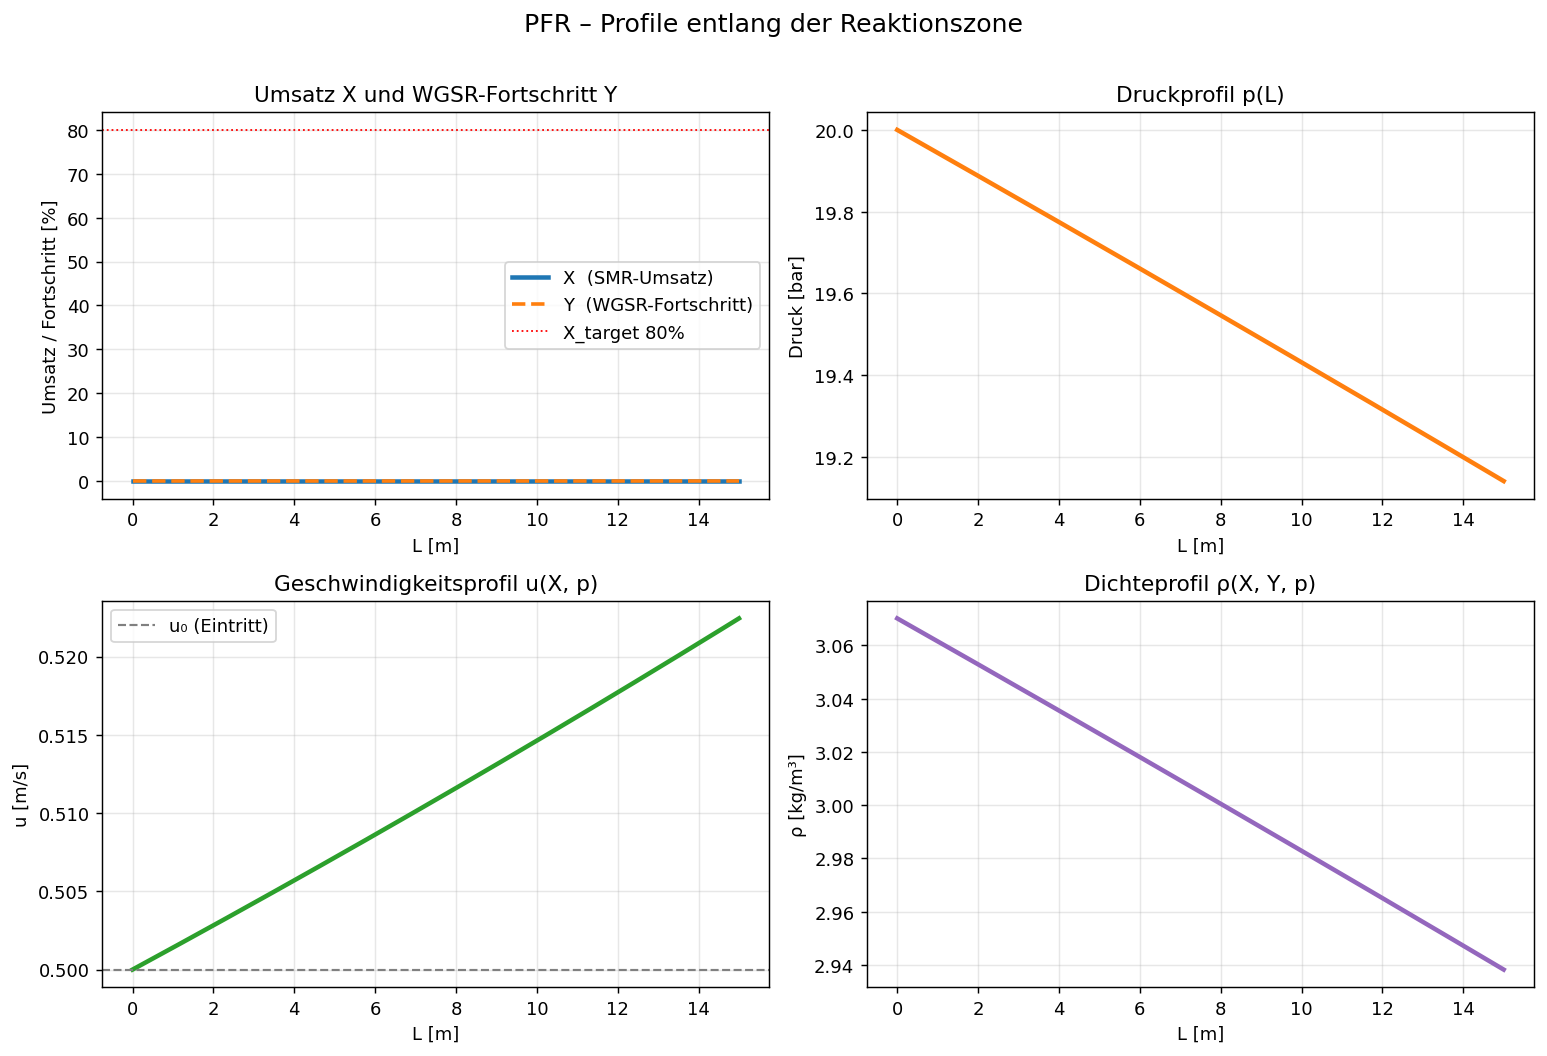

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

L = res['L']

# ── X und Y ──────────────────────────────────────────────────────────────────
ax = axes[0, 0]
ax.plot(L, res['X'] * 100, lw=2.5, label='X  (SMR-Umsatz)')
ax.plot(L, res['Y'] * 100, lw=2.0, ls='--', label='Y  (WGSR-Fortschritt)')
if 'L_required' in res:
    ax.axvline(res['L_required'], color='red', ls=':', lw=1.5)
ax.axhline(X_target * 100, color='red', ls=':', lw=1.0, label=f'X_target {X_target:.0%}')
ax.set_xlabel('L [m]');  ax.set_ylabel('Umsatz / Fortschritt [%]')
ax.set_title('Umsatz X und WGSR-Fortschritt Y');  ax.legend();  ax.grid(alpha=0.3)

# ── Druck p(L) ────────────────────────────────────────────────────────────────
ax = axes[0, 1]
ax.plot(L, res['p'] / 1e5, lw=2.5, color='tab:orange')
ax.set_xlabel('L [m]');  ax.set_ylabel('Druck [bar]')
ax.set_title('Druckprofil p(L)');  ax.grid(alpha=0.3)

# ── Geschwindigkeit u(L) ──────────────────────────────────────────────────────
ax = axes[1, 0]
ax.plot(L, res['u'], lw=2.5, color='tab:green')
ax.axhline(params.u_0, color='gray', ls='--', lw=1.2, label='u₀ (Eintritt)')
ax.set_xlabel('L [m]');  ax.set_ylabel('u [m/s]')
ax.set_title('Geschwindigkeitsprofil u(X, p)');  ax.legend();  ax.grid(alpha=0.3)

# ── Dichte ρ(L) ───────────────────────────────────────────────────────────────
ax = axes[1, 1]
ax.plot(L, res['rho'], lw=2.5, color='tab:purple')
ax.set_xlabel('L [m]');  ax.set_ylabel('ρ [kg/m³]')
ax.set_title('Dichteprofil ρ(X, Y, p)');  ax.grid(alpha=0.3)

fig.suptitle('PFR – Profile entlang der Reaktionszone', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

if 'L_required' in res:
    print(f"\n=== Auslegungsergebnis ===")
    print(f"Reaktionszonenlänge L_R  = {res['L_required']:.3f} m")
    print(f"Druckverlust Δp          = {(params.p - res['p'][-1])/1e5:.4f} bar")
    print(f"u am Austritt            = {res['u'][-1]:.4f} m/s  (Eintritt: {params.u_0:.4f} m/s)")
    print(f"ρ am Austritt            = {res['rho'][-1]:.4f} kg/m³")
    print(f"Anzahl Rohre             = {params.N_tubes}")